<a href="https://colab.research.google.com/github/marwaashfaq2004-ai/AAN-.PROJECT/blob/main/MARWA_RL_PROJECTS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

DDPG PENDULEM:

Starting DDPG Training...
Episode   0 | Episodic Reward: -1788.00 | Avg Reward: -1788.00
Episode   1 | Episodic Reward: -1320.22 | Avg Reward: -1554.11
Episode   2 | Episodic Reward: -1663.40 | Avg Reward: -1590.54
Episode   3 | Episodic Reward: -1495.32 | Avg Reward: -1566.73
Episode   4 | Episodic Reward: -1534.92 | Avg Reward: -1560.37
Episode   5 | Episodic Reward: -1487.04 | Avg Reward: -1548.15
Episode   6 | Episodic Reward: -1478.42 | Avg Reward: -1538.19
Episode   7 | Episodic Reward: -1501.70 | Avg Reward: -1533.63
Episode   8 | Episodic Reward: -1564.62 | Avg Reward: -1537.07
Episode   9 | Episodic Reward: -1017.13 | Avg Reward: -1485.08
Episode  10 | Episodic Reward: -1393.06 | Avg Reward: -1476.71
Episode  11 | Episodic Reward: -1105.40 | Avg Reward: -1445.77
Episode  12 | Episodic Reward:  -927.41 | Avg Reward: -1405.89
Episode  13 | Episodic Reward: -1074.54 | Avg Reward: -1382.23
Episode  14 | Episodic Reward:  -912.71 | Avg Reward: -1350.93
Episode  15 | Episodic Reward

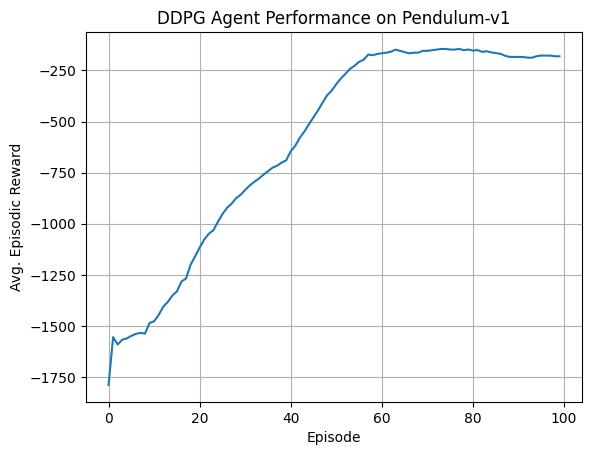

In [1]:
import gymnasium as gym
import tensorflow as tf
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt

# --- 1. SETUP ENVIRONMENT ---
problem = "Pendulum-v1"
env = gym.make(problem)

num_states = env.observation_space.shape[0]
num_actions = env.action_space.shape[0]
upper_bound = env.action_space.high[0]
lower_bound = env.action_space.low[0]

# --- 2. EXPLORATION NOISE ---
class OUActionNoise:
    def __init__(self, mean, std_deviation, theta=0.15, dt=1e-2, x_initial=None):
        self.theta = theta
        self.mean = mean
        self.std_dev = std_deviation
        self.dt = dt
        self.x_initial = x_initial
        self.reset()

    def __call__(self):
        x = (self.x_prev + self.theta * (self.mean - self.x_prev) * self.dt +
             self.std_dev * np.sqrt(self.dt) * np.random.normal(size=self.mean.shape))
        self.x_prev = x
        return x

    def reset(self):
        if self.x_initial is not None:
            self.x_prev = self.x_initial
        else:
            self.x_prev = np.zeros_like(self.mean)

# --- 3. REPLAY BUFFER ---
class Buffer:
    def __init__(self, buffer_capacity=100000, batch_size=64):
        self.buffer_capacity = buffer_capacity
        self.batch_size = batch_size
        self.buffer_counter = 0

        self.state_buffer = np.zeros((self.buffer_capacity, num_states))
        self.action_buffer = np.zeros((self.buffer_capacity, num_actions))
        self.reward_buffer = np.zeros((self.buffer_capacity, 1))
        self.next_state_buffer = np.zeros((self.buffer_capacity, num_states))

    def record(self, obs_tuple):
        index = self.buffer_counter % self.buffer_capacity
        self.state_buffer[index] = obs_tuple[0]
        self.action_buffer[index] = obs_tuple[1]
        self.reward_buffer[index] = obs_tuple[2]
        self.next_state_buffer[index] = obs_tuple[3]
        self.buffer_counter += 1

    @tf.function
    def update(self, state_batch, action_batch, reward_batch, next_state_batch):
        with tf.GradientTape() as tape:
            target_actions = target_actor(next_state_batch, training=True)
            y = reward_batch + gamma * target_critic([next_state_batch, target_actions], training=True)
            critic_value = critic_model([state_batch, action_batch], training=True)
            critic_loss = tf.math.reduce_mean(tf.math.square(y - critic_value))

        critic_grad = tape.gradient(critic_loss, critic_model.trainable_variables)
        critic_optimizer.apply_gradients(zip(critic_grad, critic_model.trainable_variables))

        with tf.GradientTape() as tape:
            actions = actor_model(state_batch, training=True)
            critic_value = critic_model([state_batch, actions], training=True)
            actor_loss = -tf.math.reduce_mean(critic_value)

        actor_grad = tape.gradient(actor_loss, actor_model.trainable_variables)
        actor_optimizer.apply_gradients(zip(actor_grad, actor_model.trainable_variables))

    def learn(self):
        record_range = min(self.buffer_counter, self.buffer_capacity)
        batch_indices = np.random.choice(record_range, self.batch_size)

        state_batch = tf.convert_to_tensor(self.state_buffer[batch_indices])
        action_batch = tf.convert_to_tensor(self.action_buffer[batch_indices])
        reward_batch = tf.cast(tf.convert_to_tensor(self.reward_buffer[batch_indices]), dtype=tf.float32)
        next_state_batch = tf.convert_to_tensor(self.next_state_buffer[batch_indices])

        self.update(state_batch, action_batch, reward_batch, next_state_batch)

# --- 4. NEURAL NETWORKS ---
def get_actor():
    last_init = tf.random_uniform_initializer(minval=-0.003, maxval=0.003)
    inputs = layers.Input(shape=(num_states,))
    out = layers.Dense(256, activation="relu")(inputs)
    out = layers.Dense(256, activation="relu")(out)
    outputs = layers.Dense(1, activation="tanh", kernel_initializer=last_init)(out)
    outputs = outputs * upper_bound
    return tf.keras.Model(inputs, outputs)

def get_critic():
    state_input = layers.Input(shape=(num_states,))
    state_out = layers.Dense(16, activation="relu")(state_input)
    state_out = layers.Dense(32, activation="relu")(state_out)

    action_input = layers.Input(shape=(num_actions,))
    action_out = layers.Dense(32, activation="relu")(action_input)

    concat = layers.Concatenate()([state_out, action_out])
    out = layers.Dense(256, activation="relu")(concat)
    out = layers.Dense(256, activation="relu")(out)
    outputs = layers.Dense(1)(out)
    return tf.keras.Model([state_input, action_input], outputs)

# --- THE FIX: Keras 3 Compatible Target Update ---
def update_target(target_model, source_model, tau):
    target_weights = target_model.get_weights()
    source_weights = source_model.get_weights()
    new_weights = []
    for t, s in zip(target_weights, source_weights):
        new_weights.append(s * tau + t * (1 - tau))
    target_model.set_weights(new_weights)

# --- 5. INITIALIZATION ---
actor_model = get_actor()
critic_model = get_critic()
target_actor = get_actor()
target_critic = get_critic()

target_actor.set_weights(actor_model.get_weights())
target_critic.set_weights(critic_model.get_weights())

critic_optimizer = tf.keras.optimizers.Adam(0.002)
actor_optimizer = tf.keras.optimizers.Adam(0.001)

total_episodes = 100
gamma = 0.99
tau = 0.005

buffer = Buffer(50000, 64)
ou_noise = OUActionNoise(mean=np.zeros(1), std_deviation=float(0.2) * np.ones(1))

ep_reward_list = []
avg_reward_list = []

# --- 6. MAIN TRAINING LOOP ---
print("Starting DDPG Training...")
for ep in range(total_episodes):
    prev_state, _ = env.reset()
    episodic_reward = 0

    while True:
        tf_prev_state = tf.expand_dims(tf.convert_to_tensor(prev_state), 0)
        action = actor_model(tf_prev_state)
        noise = ou_noise()
        action = action.numpy()[0] + noise
        action = np.clip(action, lower_bound, upper_bound)

        state, reward, terminated, truncated, _ = env.step(action)

        buffer.record((prev_state, action, reward, state))
        episodic_reward += reward
        buffer.learn()

        # Notice how these inputs are just the model variables, not the .variables lists
        update_target(target_actor, actor_model, tau)
        update_target(target_critic, critic_model, tau)

        if terminated or truncated:
            break

        prev_state = state

    ep_reward_list.append(episodic_reward)
    avg_reward = np.mean(ep_reward_list[-40:])
    avg_reward_list.append(avg_reward)
    print(f"Episode {ep:>3} | Episodic Reward: {episodic_reward:>8.2f} | Avg Reward: {avg_reward:>8.2f}")

env.close()

# --- 7. PLOT RESULTS ---
print("Training finished. Generating performance graph...")
plt.plot(avg_reward_list)
plt.xlabel("Episode")
plt.ylabel("Avg. Episodic Reward")
plt.title("DDPG Agent Performance on Pendulum-v1")
plt.grid(True)
plt.show()


FROZEN LAKE

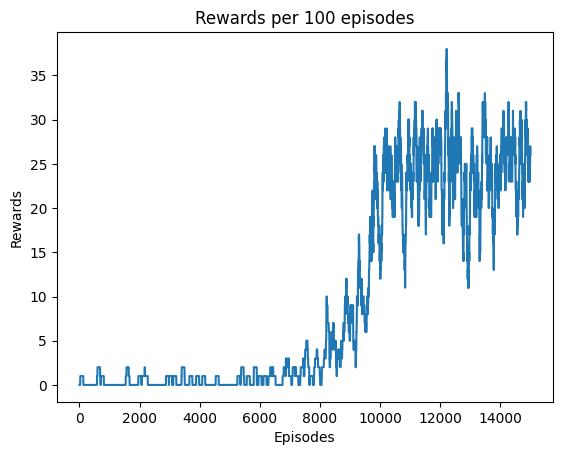

In [2]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
import pickle

def run(is_training=True, render=False):
    # 1. Setup Environment
    # The video uses the 8x8 map and toggles rendering based on the flag
    env = gym.make('FrozenLake-v1', map_name="8x8", is_slippery=True,
                   render_mode='human' if render else None)

    # 2. Initialize or Load Q-Table
    if is_training:
        q = np.zeros((env.observation_space.n, env.action_space.n))
    else:
        # Load pre-trained model if we are just testing
        with open('frozen_lake8x8.pkl', 'rb') as f:
            q = pickle.load(f)

    # Hyperparameters
    learning_rate_a = 0.9
    discount_factor_g = 0.9
    epsilon = 1.0           # Start 100% random
    epsilon_decay_rate = 0.0001
    rng = np.random.default_rng()

    episodes = 15000
    rewards_per_episode = np.zeros(episodes)

    # 3. The Core Loop
    for i in range(episodes):
        state = env.reset()[0]
        terminated = False
        truncated = False

        while(not terminated and not truncated):
            # ACTION SELECTION
            if is_training and rng.random() < epsilon:
                action = env.action_space.sample() # Explore
            else:
                action = np.argmax(q[state,:])     # Exploit

            # TAKE THE STEP
            new_state, reward, terminated, truncated, _ = env.step(action)

            # UPDATE EQUATION (Only update if training)
            if is_training:
                q[state, action] = q[state, action] + learning_rate_a * (
                    reward + discount_factor_g * np.max(q[new_state,:]) - q[state, action]
                )

            state = new_state

        # DECAY RANDOMNESS
        epsilon = max(epsilon - epsilon_decay_rate, 0)

        # Stabilize learning once exploration is finished
        if epsilon == 0:
            learning_rate_a = 0.0001

        # Track if the agent reached the goal this episode
        if reward == 1:
            rewards_per_episode[i] = 1

    env.close()

    # 4. Save the Q-table to a file
    if is_training:
        with open('frozen_lake8x8.pkl', 'wb') as f:
            pickle.dump(q, f)

    # 5. Plot the Training Graph (Moving average of last 100 episodes)
    sum_rewards = np.zeros(episodes)
    for t in range(episodes):
        sum_rewards[t] = np.sum(rewards_per_episode[max(0, t-100):(t+1)])

    plt.plot(sum_rewards)
    plt.title('Rewards per 100 episodes')
    plt.xlabel('Episodes')
    plt.ylabel('Rewards')
    plt.savefig('frozen_lake8x8.png')
    plt.show()

if __name__ == '__main__':
    # Step A: Run this first to train the model and generate the graph.
    run(is_training=True, render=False)

    # Step B: Comment out Step A, and uncomment Step B to watch the trained agent play.
    # run(is_training=False, render=True)

SVD MOUNTAIN CAR

Training Mountain Car. Please wait...
Episode:     0 | Avg: -2.00 | Min: -200.00 | Max: -200.00
Episode:   100 | Avg: -200.00 | Min: -200.00 | Max: -200.00
Episode:   200 | Avg: -200.00 | Min: -200.00 | Max: -200.00
Episode:   300 | Avg: -200.00 | Min: -200.00 | Max: -200.00
Episode:   400 | Avg: -200.00 | Min: -200.00 | Max: -200.00
Episode:   500 | Avg: -200.00 | Min: -200.00 | Max: -200.00
Episode:   600 | Avg: -200.00 | Min: -200.00 | Max: -200.00
Episode:   700 | Avg: -200.00 | Min: -200.00 | Max: -200.00
Episode:   800 | Avg: -200.00 | Min: -200.00 | Max: -200.00
Episode:   900 | Avg: -200.00 | Min: -200.00 | Max: -200.00
Episode:  1000 | Avg: -200.00 | Min: -200.00 | Max: -200.00
Episode:  1100 | Avg: -200.00 | Min: -200.00 | Max: -200.00
Episode:  1200 | Avg: -200.00 | Min: -200.00 | Max: -200.00
Episode:  1300 | Avg: -200.00 | Min: -200.00 | Max: -200.00
Episode:  1400 | Avg: -200.00 | Min: -200.00 | Max: -200.00
Episode:  1500 | Avg: -200.00 | Min: -200.00 | Max: -200.00
Epis

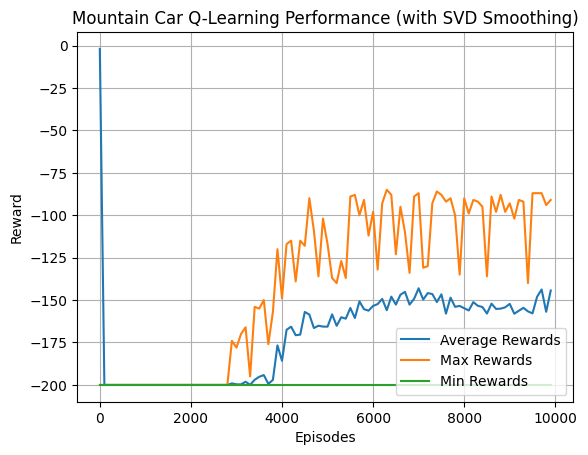

In [3]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt

# --- 1. SETUP ENVIRONMENT & DISCRETIZATION ---
env = gym.make('MountainCar-v0')

# We must force the continuous states into a 20x20 discrete grid
DISCRETE_OS_SIZE = [20, 20]
discrete_os_win_size = (env.observation_space.high - env.observation_space.low) / DISCRETE_OS_SIZE

def get_discrete_state(state):
    discrete_state = (state - env.observation_space.low) / discrete_os_win_size
    return tuple(discrete_state.astype(int))

# --- 2. INITIALIZATION ---
# Q-Table shape: (20, 20, 3)
q_table = np.random.uniform(low=-2, high=0, size=(DISCRETE_OS_SIZE + [env.action_space.n]))

LEARNING_RATE = 0.1
DISCOUNT = 0.95
EPISODES = 10000
STATS_EVERY = 100
SVD_EVERY = 50 # How often we mathematically smooth the table

epsilon = 1.0
START_EPSILON_DECAYING = 1
END_EPSILON_DECAYING = EPISODES // 2
epsilon_decay_value = epsilon / (END_EPSILON_DECAYING - START_EPSILON_DECAYING)

ep_rewards = []
aggr_ep_rewards = {'ep': [], 'avg': [], 'max': [], 'min': []}

# --- 3. CORE TRAINING LOOP ---
print("Training Mountain Car. Please wait...")
for episode in range(EPISODES):
    state, _ = env.reset()
    discrete_state = get_discrete_state(state)
    done = False
    episode_reward = 0

    while not done:
        # Explore vs Exploit
        if np.random.random() > epsilon:
            action = np.argmax(q_table[discrete_state])
        else:
            action = env.action_space.sample()

        new_state, reward, terminated, truncated, _ = env.step(action)
        episode_reward += reward
        new_discrete_state = get_discrete_state(new_state)
        done = terminated or truncated

        # The Bellman Update
        if not done:
            max_future_q = np.max(q_table[new_discrete_state])
            current_q = q_table[discrete_state + (action,)]
            new_q = (1 - LEARNING_RATE) * current_q + LEARNING_RATE * (reward + DISCOUNT * max_future_q)
            q_table[discrete_state + (action,)] = new_q

        # THE FIX: Pierce the TimeLimit wrapper to check the raw physics engine goal
        elif new_state[0] >= env.unwrapped.goal_position:
            # Reward agent heavily for reaching the flag
            q_table[discrete_state + (action,)] = 0

        discrete_state = new_discrete_state

    # Epsilon Decay
    if END_EPSILON_DECAYING >= episode >= START_EPSILON_DECAYING:
        epsilon -= epsilon_decay_value

    # SVD Matrix Smoothing (The Core Hack)
    if episode % SVD_EVERY == 0 and episode != 0:
        for a in range(env.action_space.n):
            # Decompose the 20x20 matrix for this specific action
            U, S, V = np.linalg.svd(q_table[:, :, a], full_matrices=False)
            # Truncate to top 3 singular values
            S_truncated = np.diag(S[:3])
            U_truncated = U[:, :3]
            V_truncated = V[:3, :]
            # Reconstruct the smoothed matrix
            q_table[:, :, a] = np.dot(U_truncated, np.dot(S_truncated, V_truncated))

    # --- 4. LOGGING & METRICS ---
    ep_rewards.append(episode_reward)

    if not episode % STATS_EVERY:
        average_reward = sum(ep_rewards[-STATS_EVERY:]) / STATS_EVERY
        aggr_ep_rewards['ep'].append(episode)
        aggr_ep_rewards['avg'].append(average_reward)
        aggr_ep_rewards['max'].append(max(ep_rewards[-STATS_EVERY:]))
        aggr_ep_rewards['min'].append(min(ep_rewards[-STATS_EVERY:]))
        print(f"Episode: {episode:>5d} | Avg: {average_reward:>5.2f} | Min: {min(ep_rewards[-STATS_EVERY:]):>5.2f} | Max: {max(ep_rewards[-STATS_EVERY:]):>5.2f}")

env.close()

# --- 5. PLOTTING ---
plt.plot(aggr_ep_rewards['ep'], aggr_ep_rewards['avg'], label="Average Rewards")
plt.plot(aggr_ep_rewards['ep'], aggr_ep_rewards['max'], label="Max Rewards")
plt.plot(aggr_ep_rewards['ep'], aggr_ep_rewards['min'], label="Min Rewards")
plt.title("Mountain Car Q-Learning Performance (with SVD Smoothing)")
plt.xlabel("Episodes")
plt.ylabel("Reward")
plt.legend(loc=4)
plt.grid(True)
plt.show()